want to plot the georefernced hsi

In [2]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils import georef
import config

# IMPORTANT: Reload the module to get the latest changes (track_start/track_end parameters)
importlib.reload(georef)
from utils.georef import *

print("✅ Module reloaded successfully!")

✅ Module reloaded successfully!


In [3]:
# Load transect from the output folder specified in config
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        "rad_uhi_20241029_115057_1",
        "rad_uhi_20241029_115057_2",
        "rad_uhi_20241029_115057_3",
        "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
    ]
)
cube.describe()

%matplotlib inline



📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_1
  rad_uhi_20241029_115057_1: Using GRIDDED format (T=1333, S=968)
   • rad_uhi_20241029_115057_2
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
   • rad_uhi_20241029_115057_3
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using G

In [3]:
stop run all

SyntaxError: invalid syntax (3537407434.py, line 1)

  rad_uhi_20241029_115057_1: Using GRIDDED format (T=1333, S=968)
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:740: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


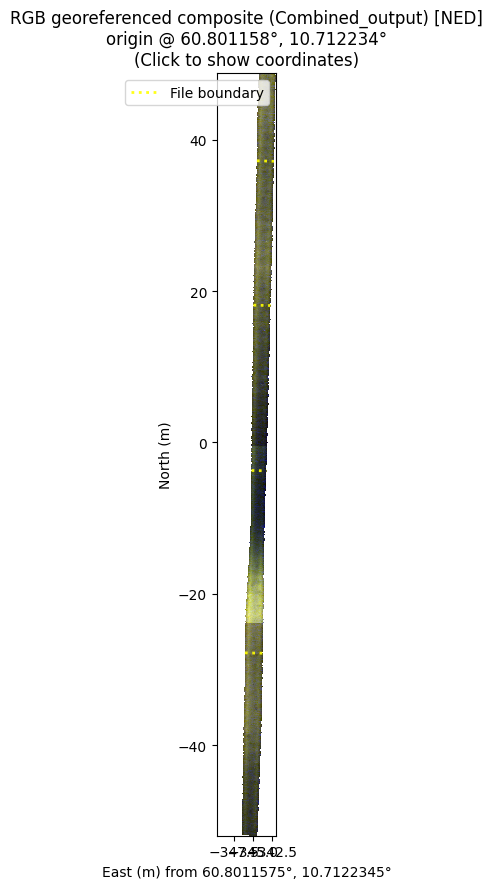

In [ ]:
cube.plot_georef(coordinate_system="NED", show_file_boundaries=True, interactive=True)

In [4]:
# Plot georeferenced HSI with navigation trajectory
# The plot_georef_with_trajectory() method is now part of the CombinedTransectCube class!
# Using origin from config

%matplotlib qt


origin = (config.LAT0, config.LON0, config.H0)

# Option 1: LATLON mode with trajectory (default)
fig, ax = cube.plot_georef_with_trajectory(
    coordinate_system="LATLON",  # or None
    show_trajectory=True,
    trajectory_color="red",
    trajectory_linewidth=1.5,
    trajectory_alpha=0.7,
    interactive=True,
)

# Option 2: NED mode with trajectory
# fig, ax = cube.plot_georef_with_trajectory(
#     coordinate_system="NED",
#     origin=origin,
#     show_trajectory=True,
#     trajectory_color="cyan",
#     trajectory_linewidth=1.5,
#     interactive=True,
# )

# Option 3: ECEF mode with trajectory
# fig, ax = cube.plot_georef_with_trajectory(
#     coordinate_system="ECEF",
#     use_local_origin=True,
#     origin=origin,
#     show_trajectory=True,
#     trajectory_color="yellow",
#     trajectory_linewidth=1.5,
#     interactive=True,
# )

  rad_uhi_20241029_115057_1: Using GRIDDED format (T=1333, S=968)
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:826: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


Loaded 232670 navigation records from E:\mjosa_new\navigation_data\nav_data_merged.csv
Time range: 1730196822.84 to 1730207699.44
✓ Added trajectory with 232670 points


In [ ]:
def print_processing_statistics(stats_file_path=None):
    """
    Load and print processing statistics from JSON file.

    Parameters:
    -----------
    stats_file_path : str or Path, optional
        Path to the statistics JSON file. If None, uses config.OUTPUT_FOLDER/processing_statistics.json
    """
    import json
    from pathlib import Path
    from datetime import datetime

    # Determine stats file path
    if stats_file_path is None:
        stats_file = Path(config.OUTPUT_FOLDER) / "processing_statistics.json"
    else:
        stats_file = Path(stats_file_path)

    if not stats_file.exists():
        print(f"❌ Statistics file not found: {stats_file}")
        print("Run main.py first to generate the statistics file.")
        return None

    # Load statistics
    with open(stats_file, "r") as f:
        stats = json.load(f)

    # Helper function to safely get nested dict values
    def get_nested(data, *keys, default="N/A"):
        """Safely get nested dictionary values."""
        try:
            for key in keys:
                data = data[key]
            return data
        except (KeyError, TypeError):
            return default

    # Helper to convert unix timestamp to UTC
    def unix_to_utc(timestamp):
        """Convert unix timestamp to UTC string."""
        try:
            return datetime.utcfromtimestamp(float(timestamp)).strftime(
                "%Y-%m-%d %H:%M:%S UTC"
            )
        except:
            return "N/A"

    print("=" * 80)
    print("PROCESSING STATISTICS")
    print("=" * 80)

    # Session info
    print("\n📅 SESSION INFO")
    print(f"  Started: {get_nested(stats, 'processing_session', 'start_time')}")
    print(f"  Finished: {get_nested(stats, 'processing_session', 'end_time')}")
    duration_sec = get_nested(stats, "processing_session", "duration_sec", default=0)
    duration_human = get_nested(
        stats, "processing_session", "duration_human", default="N/A"
    )
    if duration_sec != "N/A" and duration_sec != 0:
        print(f"  Processing duration: {duration_human}")

    # Configuration
    print("\n⚙️  CONFIGURATION")
    print(
        f"  Navigation CSV: {Path(get_nested(stats, 'configuration', 'nav_csv', default='')).name}"
    )
    print(
        f"  MBES GeoTIFF: {Path(get_nested(stats, 'configuration', 'mbes_geotiff', default='')).name}"
    )
    print(
        f"  Output folder: {Path(get_nested(stats, 'configuration', 'output_folder', default='')).name}"
    )
    print(
        f"  Max ray length: {get_nested(stats, 'configuration', 'max_ray_length_m', default=0):.1f} m"
    )
    print(
        f"  Failure threshold: {get_nested(stats, 'configuration', 'early_failure_threshold_pct', default=0):.1f}%"
    )

    # Navigation data
    print("\n🧭 NAVIGATION DATA")
    nav_records = get_nested(stats, "navigation_data", "total_records", default=0)
    print(f"  Total records: {nav_records:,} (navigation data points in CSV)")
    time_start = get_nested(stats, "navigation_data", "time_range", "start", default=0)
    time_end = get_nested(stats, "navigation_data", "time_range", "end", default=0)
    time_dur = get_nested(
        stats, "navigation_data", "time_range", "duration_sec", default=0
    )
    print(f"  Start time: {time_start:.2f} ({unix_to_utc(time_start)})")
    print(f"  End time: {time_end:.2f} ({unix_to_utc(time_end)})")
    print(f"  Duration: {time_dur:.1f} s ({time_dur/60:.1f} min)")

    # MBES mesh
    print("\n🗺️  MBES MESH")
    print(f"  Vertices: {get_nested(stats, 'mbes_mesh', 'n_vertices', default=0):,}")
    print(f"  Faces: {get_nested(stats, 'mbes_mesh', 'n_faces', default=0):,}")
    x_min = get_nested(stats, "mbes_mesh", "bounds", "x_min", default=0)
    x_max = get_nested(stats, "mbes_mesh", "bounds", "x_max", default=0)
    y_min = get_nested(stats, "mbes_mesh", "bounds", "y_min", default=0)
    y_max = get_nested(stats, "mbes_mesh", "bounds", "y_max", default=0)
    z_min = get_nested(stats, "mbes_mesh", "bounds", "z_min", default=0)
    z_max = get_nested(stats, "mbes_mesh", "bounds", "z_max", default=0)
    print(f"  Bounds (X): [{x_min:.2f}, {x_max:.2f}] m")
    print(f"  Bounds (Y): [{y_min:.2f}, {y_max:.2f}] m")
    print(f"  Bounds (Z): [{z_min:.2f}, {z_max:.2f}] m")

    # Camera
    print("\n📷 CAMERA CALIBRATION")
    focal = get_nested(stats, "camera_calibration", "focal_length", default=0)
    cx = get_nested(stats, "camera_calibration", "principal_point", default=0)
    width = get_nested(stats, "camera_calibration", "width_pixels", default=0)
    print(f"  Focal length: {focal:.2f} px")
    print(f"  Principal point: {cx:.2f} px")
    print(f"  Image width: {width:.0f} px")

    # Combined transect statistics (MAIN SECTION)
    if "aggregated_statistics" in stats:
        print("\n" + "=" * 80)
        print("📊 COMBINED TRANSECT STATISTICS (All H5 files together)")
        print("=" * 80)
        agg = stats["aggregated_statistics"]

        # File processing summary
        print(f"\n  Files processed: {get_nested(agg, 'total_files', default=0)} total")
        print(f"    ✅ Successful: {get_nested(agg, 'successful_files', default=0)}")
        print(f"    ❌ Failed: {get_nested(agg, 'failed_files', default=0)}")

        # HSI and ray tracing
        print(f"\n  HSI Data:")
        print(f"    Total frames: {get_nested(agg, 'total_frames', default=0):,}")
        print(f"    Total rays: {get_nested(agg, 'total_rays', default=0):,}")
        print(f"    Successful hits: {get_nested(agg, 'total_hits', default=0):,}")
        print(
            f"    Overall success rate: {get_nested(agg, 'overall_success_rate_pct', default=0):.2f}%"
        )

        # Mission metrics (combined)
        if "mission_metrics" in agg:
            print(f"\n  📏 Mission Metrics (entire transect):")
            dist_m = get_nested(agg, "mission_metrics", "total_distance_m", default=0)
            dur_sec = get_nested(
                agg, "mission_metrics", "total_duration_sec", default=0
            )
            speed_ms = get_nested(agg, "mission_metrics", "avg_speed_ms", default=0)
            speed_kmh = get_nested(agg, "mission_metrics", "avg_speed_kmh", default=0)
            print(f"    Total distance: {dist_m:.1f} m ({dist_m/1000:.3f} km)")
            print(f"    Total survey duration: {dur_sec:.1f} s ({dur_sec/60:.1f} min)")
            print(f"    Average speed: {speed_ms:.2f} m/s ({speed_kmh:.2f} km/h)")

        # Coverage metrics (combined)
        if "coverage_metrics" in agg:
            print(f"\n  📐 Coverage Metrics (entire transect):")
            area_m2 = get_nested(
                agg, "coverage_metrics", "total_coverage_area_m2", default=0
            )
            mean_swath = get_nested(
                agg, "coverage_metrics", "mean_swath_width_m", default=0
            )
            min_swath = get_nested(
                agg, "coverage_metrics", "min_swath_width_m", default=0
            )
            max_swath = get_nested(
                agg, "coverage_metrics", "max_swath_width_m", default=0
            )
            eff_pct = get_nested(
                agg, "coverage_metrics", "mean_coverage_efficiency_pct", default=0
            )
            print(
                f"    Total covered area: {area_m2:.1f} m² ({area_m2/10000:.4f} hectares)"
            )
            print(f"    Mean swath width: {mean_swath:.2f} m")
            print(f"    Swath width range: [{min_swath:.2f}, {max_swath:.2f}] m")
            print(f"    Coverage efficiency: {eff_pct:.1f}%")
            print(f"      (= covered area / survey bounding box area)")

    # Individual files
    if "individual_files" in stats and len(stats["individual_files"]) > 0:
        print("\n" + "=" * 80)
        print("📄 INDIVIDUAL FILE STATISTICS")
        print("=" * 80)

        for i, file_stat in enumerate(stats["individual_files"], 1):
            if file_stat.get("status") == "failed":
                print(
                    f"\n[{i}] {get_nested(file_stat, 'filename', default='Unknown')} ❌ FAILED"
                )
                continue

            print(f"\n[{i}] {get_nested(file_stat, 'filename', default='Unknown')}")
            print(
                f"  ⏱️  Processing time: {get_nested(file_stat, 'processing_time', default='N/A')}"
            )

            # HSI data
            if "hsi_data" in file_stat:
                hsi = file_stat["hsi_data"]
                n_frames = get_nested(hsi, "n_frames", default=0)
                n_slits = get_nested(hsi, "n_slits", default=0)
                n_bands = get_nested(hsi, "n_bands", default=0)
                duration = get_nested(hsi, "time_range", "duration_sec", default=0)
                time_start_file = get_nested(hsi, "time_range", "start", default=0)
                print(
                    f"  📸 HSI: {n_frames} frames × {n_slits} slits × {n_bands} bands"
                )
                print(f"      Duration: {duration:.1f} s")
                print(f"      Start: {unix_to_utc(time_start_file)}")

            # Navigation
            if "navigation" in file_stat:
                nav = file_stat["navigation"]
                print(f"  🧭 Navigation:")
                depth_min = get_nested(nav, "depth_range", "min", default=0)
                depth_max = get_nested(nav, "depth_range", "max", default=0)
                depth_mean = get_nested(nav, "depth_range", "mean", default=0)
                print(
                    f"      Depth: {depth_min:.2f} to {depth_max:.2f} m (mean: {depth_mean:.2f} m)"
                )

                roll_min = get_nested(nav, "attitude_ranges", "roll", "min", default=0)
                roll_max = get_nested(nav, "attitude_ranges", "roll", "max", default=0)
                roll_std = get_nested(nav, "attitude_ranges", "roll", "std", default=0)
                pitch_min = get_nested(
                    nav, "attitude_ranges", "pitch", "min", default=0
                )
                pitch_max = get_nested(
                    nav, "attitude_ranges", "pitch", "max", default=0
                )
                pitch_std = get_nested(
                    nav, "attitude_ranges", "pitch", "std", default=0
                )
                print(
                    f"      Roll: {roll_min:.2f}° to {roll_max:.2f}° (σ={roll_std:.2f}°)"
                )
                print(
                    f"      Pitch: {pitch_min:.2f}° to {pitch_max:.2f}° (σ={pitch_std:.2f}°)"
                )

            # Mission metrics
            if "mission_metrics" in file_stat:
                mission = file_stat["mission_metrics"]
                dist = get_nested(mission, "total_distance_m", default=0)
                speed_ms = get_nested(mission, "avg_speed_ms", default=0)
                speed_kmh = get_nested(mission, "avg_speed_kmh", default=0)
                print(f"  📏 Mission:")
                print(f"      Distance: {dist:.1f} m")
                print(f"      Speed: {speed_ms:.2f} m/s ({speed_kmh:.2f} km/h)")

            # Coverage
            if "coverage_metrics" in file_stat:
                coverage = file_stat["coverage_metrics"]
                area = get_nested(
                    coverage, "coverage_area", "total_covered_m2", default=0
                )
                swath_mean = get_nested(coverage, "swath_width", "mean_m", default=0)
                swath_std = get_nested(coverage, "swath_width", "std_m", default=0)
                eff = get_nested(coverage, "coverage_area", "efficiency_pct", default=0)
                print(f"  📐 Coverage:")
                print(f"      Area: {area:.1f} m²")
                print(f"      Swath width: {swath_mean:.2f} ± {swath_std:.2f} m")
                print(f"      Efficiency: {eff:.1f}%")

            # Ray tracing
            if "ray_tracing" in file_stat:
                rt = file_stat["ray_tracing"]
                success_pct = get_nested(rt, "success_rate_pct", default=0)
                hits = get_nested(rt, "successful_hits", default=0)
                total = get_nested(rt, "total_rays", default=1)
                trimesh_hits = get_nested(rt, "trimesh_hits", default=0)
                pv_retries = get_nested(rt, "pyvista_retries", default=0)
                pv_recoveries = get_nested(rt, "pyvista_recoveries", default=0)
                print(f"  🎯 Ray tracing:")
                print(f"      Success rate: {success_pct:.2f}% ({hits:,}/{total:,})")
                print(f"      Trimesh hits: {trimesh_hits:,}")
                print(
                    f"      PyVista retries: {pv_retries:,} (recovered: {pv_recoveries:,})"
                )

    print("\n" + "=" * 80)
    print(f"Statistics loaded from: {stats_file}")
    print("=" * 80)

    return stats


# Call the function
stats = print_processing_statistics()

PROCESSING STATISTICS

📅 SESSION INFO
  Started: 2025-10-09 10:28:14
  Finished: 2025-10-09 10:36:12
  Processing duration: 7m 58s

⚙️  CONFIGURATION
  Navigation CSV: nav_data_merged.csv
  MBES GeoTIFF: geotiff_2.tif
  Output folder: output
  Max ray length: 100.0 m
  Failure threshold: 50.0%

🧭 NAVIGATION DATA
  Total records: 232,670 (navigation data points in CSV)
  Start time: 1730196822.84 (2024-10-29 10:13:42 UTC)
  End time: 1730207699.44 (2024-10-29 13:14:59 UTC)
  Duration: 10876.6 s (181.3 min)

🗺️  MBES MESH
  Vertices: 7,390,592
  Faces: 7,383,936
  Bounds (X): [592829.45, 592857.59] m
  Bounds (Y): [6741790.71, 6741895.67] m
  Bounds (Z): [-136.01, -110.83] m

📷 CAMERA CALIBRATION
  Focal length: 930.63 px
  Principal point: 484.75 px
  Image width: 968 px

📊 COMBINED TRANSECT STATISTICS (All H5 files together)

  Files processed: 6 total
    ✅ Successful: 6
    ❌ Failed: 0

  HSI Data:
    Total frames: 10,586
    Total rays: 10,247,248
    Successful hits: 10,094,582
  

# lets try to make the figures we need for the paper

  rad_uhi_20241029_115057_1: Using GRIDDED format (T=1333, S=968)
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
📊 Plotting tracks 8637–9708 (shape: 1072 × 968)
💡 Interactive mode: Click on the plot to display coordinates
📊 Plotting tracks 8637–9708 (shape: 1072 × 968)
💡 Interactive mode: Click on the plot to display coordinates


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:632: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


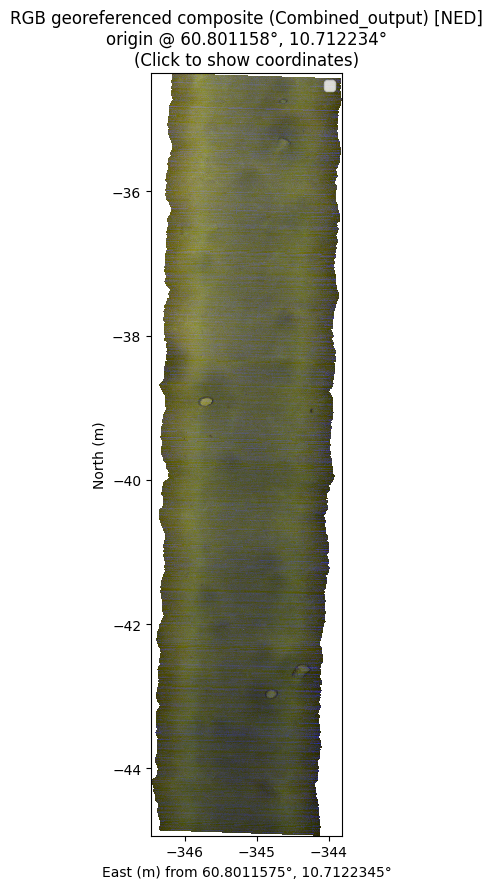

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    show_file_boundaries=True,
    interactive=True,
    track_start=8637,
    track_end=9709,
)

In [ ]:
# Apply illumination correction to the cube
# This creates R_corrected, G_corrected, B_corrected attributes
cube.apply_illumination_correction()

# Now you can plot with corrected data
# cube.plot_georef(coordinate_system="NED", use_corrected=True, show_file_boundaries=True, interactive=True)

🔄 Loading full data cubes and applying illumination correction...
   • Loading rad_uhi_20241029_115057_1...
   • Loading rad_uhi_20241029_115057_2...
   • Loading rad_uhi_20241029_115057_3...
   • Loading rad_uhi_20241029_115057_4...
   • Loading rad_uhi_20241029_115057_5...


MemoryError: Unable to allocate 7.90 GiB for an array with shape (10431, 968, 210) and data type float32

  rad_uhi_20241029_115057_1: Using GRIDDED format (T=1333, S=968)
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
📊 Plotting tracks 8637–9708 (shape: 1072 × 968)
💡 Interactive mode: Click on the plot to display coordinates
📊 Plotting tracks 8637–9708 (shape: 1072 × 968)
💡 Interactive mode: Click on the plot to display coordinates


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:657: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:765: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:765: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


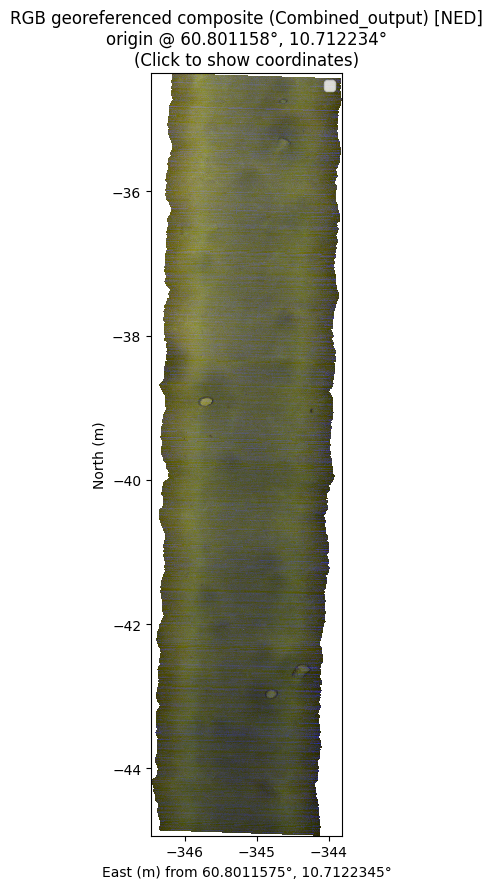

c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:503: RuntimeWarning: All-NaN slice encountered
  m, M = np.nanmin(C), np.nanmax(C)


📊 Plotting tracks 8637–9708 (shape: 1072 × 968)
💡 Interactive mode: Click on the plot to display coordinates


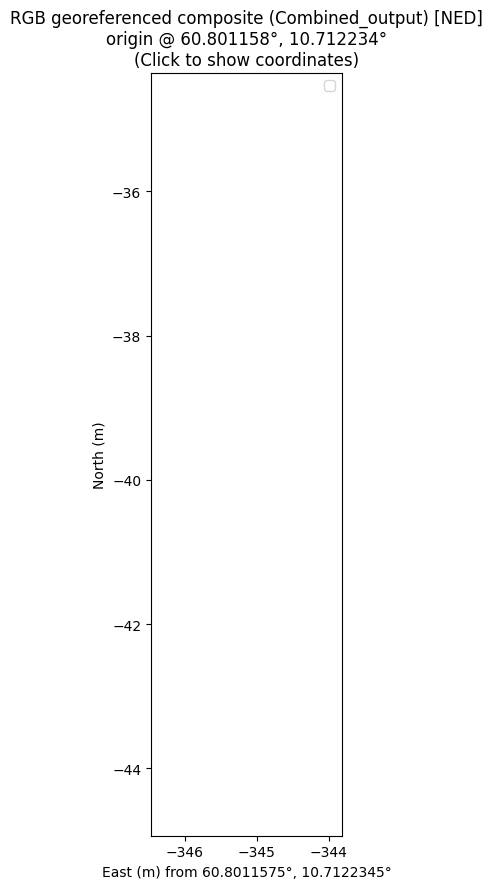

In [ ]:
cube.plot_georef(
    coordinate_system="NED",
    show_file_boundaries=True,
    interactive=True,
    track_start=8637,
    track_end=9709,
)

cube.plot_georef(
    coordinate_system="NED",
    show_file_boundaries=True,
    interactive=True,
    track_start=8637,
    track_end=9709,
    use_corrected=True,  # ← NEW PARAMETER!
)

# plot mbes with UHI

In [4]:
%matplotlib qt
fig, ax = cube.plot_georef_with_trajectory(
    coordinate_system="LATLON",  # or "NED"
    show_trajectory=True,
    # MBES:
    mbes_geotiff_path=config.MBES_GEOTIFF,
    mbes_epsg=getattr(config, "EPSG_MBES", 32633),  # example
    mbes_cmap="Greys",
    mbes_alpha=0.6,
    mbes_step=6,  # heavier decimation if big raster
)

  rad_uhi_20241029_115057_1: Using GRIDDED format (T=1333, S=968)
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)


c:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\havard_repo\from_Leo_usb\gref4hsi\x_gref4hsi_by_liu\utils\georef.py:826: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


✓ MBES underlay added from 'E:\mjosa_new\DTM\geotiff_2.tif' (EPSG:32632), step=6
Loaded 232670 navigation records from E:\mjosa_new\navigation_data\nav_data_merged.csv
Time range: 1730196822.84 to 1730207699.44
✓ Added trajectory with 232670 points
